# Leverage Mechanism

This notebook inspects the mechanism behind Figure 2: leverage scores preserve marker ranking when abundance changes and surface low-variance/high-leverage genes.

In [1]:
from pathlib import Path
import os
import sys


def find_repo_root(start):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "repro").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise RuntimeError("Could not locate repository root; start Jupyter from the repository or notebooks directory.")


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

from repro.paths import get_runtime_config

CONFIG = get_runtime_config(data_dir="data", results_dir="results")
DATA_DIR = CONFIG.data_dir
RESULTS_DIR = CONFIG.results_dir
RUN_MODE = CONFIG.run_mode

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def path_label(path, env_name):
    raw = os.environ.get(env_name)
    if raw and Path(raw).is_absolute():
        return f"${env_name}"
    try:
        return str(Path(path).resolve().relative_to(REPO_ROOT))
    except ValueError:
        return str(path)


config = pd.DataFrame([
    {"setting": "run_mode", "value": RUN_MODE},
    {"setting": "data_dir", "value": path_label(DATA_DIR, "FD_DATA_DIR")},
    {"setting": "results_dir", "value": path_label(RESULTS_DIR, "FD_RESULTS_DIR")},
])
display(config)


,setting,value
0,run_mode,smoke
1,data_dir,data
2,results_dir,results


## Build or Load Reference Signatures

In [2]:

from repro.paths import missing_inputs_message
from repro.signatures import (
    build_signature_matrix,
    experiment1_abundance_invariance,
    experiment2_gene_quadrant,
    load_mouse_brain_reference,
)

if RUN_MODE == "full":
    mouse_root = DATA_DIR / "mouse_brain"
    required = [mouse_root / "scrna_reference.h5ad"]
    message = missing_inputs_message(required, "bash scripts/download_cell2location_data.sh ./data/mouse_brain")
    if message:
        raise FileNotFoundError(message)
    adata = load_mouse_brain_reference(DATA_DIR)
    X, cell_types = build_signature_matrix(adata, "cell_type", normalize="log_cpm")
    gene_names = list(adata.var_names)
    out_dir = RESULTS_DIR / "leverage_deep_dive"
else:
    rng = np.random.default_rng(7)
    n_types, n_genes = 8, 240
    cell_types = [f"type_{i}" for i in range(n_types)]
    gene_names = [f"Gene{i:03d}" for i in range(n_genes)]
    X = rng.gamma(1.2, 0.8, size=(n_types, n_genes))
    for i in range(n_types):
        start = i * 12
        X[i, start:start + 12] += rng.gamma(6, 1.5, size=12)
    X = np.log1p(X / (X.sum(axis=1, keepdims=True) + 1e-10) * 1e4)
    out_dir = None

abundance_df = experiment1_abundance_invariance(X, cell_types, gene_names, out_dir)
quadrant_df = experiment2_gene_quadrant(X, gene_names, out_dir)
display(abundance_df)
display(quadrant_df["quadrant"].value_counts().rename_axis("quadrant").reset_index(name="genes"))


,abundance_dominant_pct,avg_var_rank_dominant,avg_lev_rank_dominant,dominant_type
0,100,98.54,102.06,type_1
1,80,127.78,125.78,type_1
2,60,148.00,142.92,type_1
3,40,156.44,141.82,type_1
4,20,154.56,133.08,type_1
5,10,149.80,131.56,type_1
6,5,146.16,127.92,type_1


,quadrant,genes
0,High Var / High Lev,107
1,Low Var / Low Lev,107
2,Low Var / High Lev,13
3,High Var / Low Lev,13


## Mechanism Preview

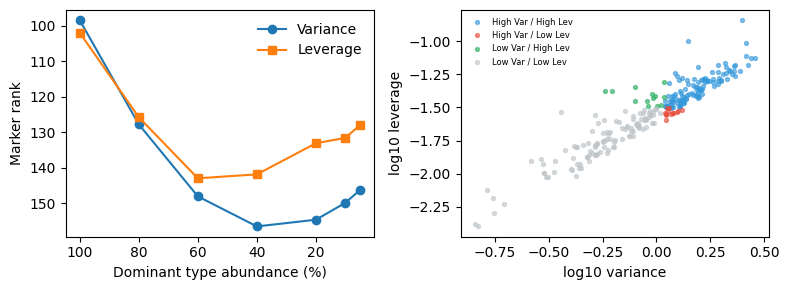

In [3]:

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot(abundance_df["abundance_dominant_pct"], abundance_df["avg_var_rank_dominant"], "o-", label="Variance")
axes[0].plot(abundance_df["abundance_dominant_pct"], abundance_df["avg_lev_rank_dominant"], "s-", label="Leverage")
axes[0].invert_xaxis()
axes[0].invert_yaxis()
axes[0].set_xlabel("Dominant type abundance (%)")
axes[0].set_ylabel("Marker rank")
axes[0].legend(frameon=False)

colors = {
    "Low Var / High Lev": "#27ae60",
    "High Var / Low Lev": "#e74c3c",
    "High Var / High Lev": "#3498db",
    "Low Var / Low Lev": "#bdc3c7",
}
for quadrant, sub in quadrant_df.groupby("quadrant"):
    axes[1].scatter(sub["log_variance"], sub["log_leverage"], s=8, alpha=0.6, label=quadrant, c=colors.get(quadrant, "gray"))
axes[1].set_xlabel("log10 variance")
axes[1].set_ylabel("log10 leverage")
axes[1].legend(frameon=False, fontsize=6)
plt.tight_layout()
plt.show()
